### Experimental Setup

In [1]:
FEATURE_SELECTION_METHOD = "WOA"
DEEP_LEARNING_CATEGORY = "Attention"
MODEL_ARCHITECTURE = "DistilGPT2"
DATASET_NAME = "SysCall"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu 

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Import Necessary Packages

In [2]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Visualization
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
import sklearn
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    LSTM,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ============================================================
# Transformers
# ============================================================
import transformers
from transformers import (
    BertTokenizer,
    GPT2Tokenizer,
    TFBertModel,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
from flaml import AutoML
import joblib

### Version Checking

In [3]:
print("=" * 60)
print("Python Version")
print("=" * 60)
print(sys.version)

print("\n" + "=" * 60)
print("Core Library Versions")
print("=" * 60)
print(f"NumPy            : {np.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"Matplotlib       : {matplotlib.__version__}")
print(f"Seaborn          : {sns.__version__}")
print(f"SciPy            : {scipy.__version__}")
print(f"Scikit-learn     : {sklearn.__version__}")
print(f"TensorFlow       : {tf.__version__}")
print(f"Transformers     : {transformers.__version__}")
print(f"Joblib           : {joblib.__version__}")

print("\n" + "=" * 60)
print("Keras Version")
print("=" * 60)
print(f"Keras (tf.keras) : {tf.keras.__version__}")

print("\n" + "=" * 60)
print("CUDA / GPU Info")
print("=" * 60)
print(f"Built with CUDA  : {tf.test.is_built_with_cuda()}")
print(f"GPU Available    : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPUs             : {tf.config.list_physical_devices('GPU')}")

Python Version
3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]

Core Library Versions
NumPy            : 1.23.5
Pandas           : 1.5.3
Matplotlib       : 3.7.1
Seaborn          : 0.12.2
SciPy            : 1.9.3
Scikit-learn     : 1.2.2
TensorFlow       : 2.11.0
Transformers     : 4.38.2
Joblib           : 1.3.2

Keras Version
Keras (tf.keras) : 2.11.0

CUDA / GPU Info
Built with CUDA  : True
GPU Available    : True
GPUs             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### GPU Checking

In [4]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Sun Apr 12 13:03:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   32C    P8             15W /  300W |   48502MiB /  49140MiB |     19%      Default |
|           

### GPU Status Checking

In [5]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [6]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [7]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_System_Calls,Unique_System_Calls,Unique_System_Calls_List,File_Operations,Unique_File_Operations,Unique_File_Operations_List,Memory_Operations,Unique_Memory_Operations,Unique_Memory_Operations_List,...,Filesystem_Operations,Unique_Filesystem_Operations,Unique_Filesystem_Operations_List,Security_Operations,Unique_Security_Operations,Unique_Security_Operations_List,Miscellaneous_Operations,Unique_Miscellaneous_Operations,Unique_Miscellaneous_Operations_List,Level
0,10Cent10-999.0.4.tar.gz,4859,33,"munmap, newfstatat, openat, fstat, ioctl, lsee...",3945,12,"newfstatat, mkdir, fstat, write, unlink, read,...",433,4,"munmap, mmap, mprotect, brk",...,0,0,NaN,0,0,NaN,7,2,"getrandom, uname",1
1,10Cent11-999.0.4.tar.gz,1423,34,"read, getpid, ioctl, write, wait4, close, newf...",1014,8,"newfstatat, write, fstat, read, rmdir, lseek, ...",25,4,"munmap, brk, mprotect, mmap",...,0,0,NaN,0,0,NaN,2,1,uname,1
2,11Cent-999.0.0.tar.gz,9966,42,"newfstatat, mkdir, openat, fstat, write, close...",8556,12,"newfstatat, mkdir, fstat, write, unlink, read,...",204,5,"mremap, munmap, brk, mmap, mprotect",...,0,0,NaN,0,0,NaN,8,2,"getrandom, uname",1
3,11Cent-999.0.1.tar.gz,1049,33,"restart_syscall, getsockopt, newfstatat, opena...",782,8,"newfstatat, openat, fstat, write, read, rmdir,...",11,3,"munmap, brk, mmap",...,0,0,NaN,0,0,NaN,2,1,uname,1
4,11Cent-999.0.2.tar.gz,791,33,"restart_syscall, read, brk, poll, uname, newfs...",625,9,"newfstatat, fstat, write, unlink, read, rmdir,...",5,3,"munmap, brk, mmap",...,0,0,NaN,0,0,NaN,2,1,uname,1


### Clear Backend Session

In [8]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Selected Features

In [9]:
selected_features = ['Unique_Process_Management_Operations','Unique_IO_Operations_List','Unique_Time_Operations_List','Unique_IPC_Operations_List','Unique_Security_Operations_List','Unique_Miscellaneous_Operations_List']

### Data Preprocessing

In [10]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 6)
Validation set shape   : (2141, 6)
Test set shape         : (2141, 6)


### Setup OUTPUT_DIR

In [11]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2'

### Model

In [12]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# =========================================================
# Detect categorical and numeric columns
# =========================================================

categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns


# =========================================================
# Convert each row into a single text string
# =========================================================

def row_to_text(row):

    text = " ".join([f"{col}:{row[col]}" for col in categorical_cols])
    
    return text

X_train_text = X_train.apply(row_to_text, axis=1)
X_val_text   = X_val.apply(row_to_text, axis=1)
X_test_text  = X_test.apply(row_to_text, axis=1)


# =========================================================
# Load DistilGPT2 tokenizer and model
# =========================================================

MODEL = "distilgpt2"
tokenizer = GPT2Tokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token
gpt_model = TFGPT2Model.from_pretrained(MODEL)


# =========================================================
# Tokenization
# =========================================================

MAX_LEN = 64

def encode_texts(texts):

    enc = tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )

    return enc

train_enc = encode_texts(X_train_text)
val_enc   = encode_texts(X_val_text)
test_enc  = encode_texts(X_test_text)


# =========================================================
# Process numeric features
# =========================================================

if len(numeric_cols) > 0:

    scaler = StandardScaler()

    X_train_num = scaler.fit_transform(X_train[numeric_cols])
    X_val_num   = scaler.transform(X_val[numeric_cols])
    X_test_num  = scaler.transform(X_test[numeric_cols])

else:

    X_train_num = np.empty((len(X_train), 0))
    X_val_num   = np.empty((len(X_val), 0))
    X_test_num  = np.empty((len(X_test), 0))

# Convert to float32
X_train_num = X_train_num.astype(np.float32)
X_val_num   = X_val_num.astype(np.float32)
X_test_num  = X_test_num.astype(np.float32)


# =========================================================
# Labels
# =========================================================

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# =========================================================
# Callbacks
# =========================================================

checkpoint_cb = ModelCheckpoint(
    MODEL_NAME,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=200,
    restore_best_weights=True
)


# =========================================================
# Build DistilGPT2 Hybrid Model
# =========================================================

input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)
attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)

# Transformer output
gpt_outputs = gpt_model(
    input_ids,
    attention_mask=attention_mask
)

# Use last token representation
text_features = gpt_outputs.last_hidden_state[:, -1, :]

# Numeric input
num_input = tf.keras.Input(shape=(X_train_num.shape[1],))
num_branch = layers.Dense(64, activation="relu")(num_input)
num_branch = layers.Dropout(0.2)(num_branch)

# Combine text + numeric
x = layers.Concatenate()([text_features, num_branch])

# Classification head
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)

output = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(
    inputs=[input_ids, attention_mask, num_input],
    outputs=output
)

model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

All PyTorch model weights were used when initializing TFGPT2Model.

All the weights of TFGPT2Model were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2Model for predictions without further training.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 input_3 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 tfgpt2_model (TFGPT2Model)     TFBaseModelOutputWi  81912576    ['input_1[0][0]',                
                                thPastAndCrossAtten               'input_2[0][0]']            

### Compime the Model

In [13]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(

    [
        train_enc["input_ids"],
        train_enc["attention_mask"],
        X_train_num
    ],

    y_train,

    validation_data=(

        [
            val_enc["input_ids"],
            val_enc["attention_mask"],
            X_val_num
        ],

        y_val
    ),

    epochs=200,
    batch_size=16,

    callbacks=[
        checkpoint_cb,
        reduce_lr_cb,
        early_stop_cb
    ]

)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
625/625 [==============================] - ETA: 0s - loss: 0.1813 - accuracy: 0.9101
Epoch 1: val_accuracy improved from -inf to 0.93788, saving model to Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2/Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2.h5
625/625 [==============================] - 41s 55ms/step - loss: 0.1813 - accuracy: 0.9101 - val_loss: 0.1091 - val_accuracy: 0.9379 - lr: 1.0000e-04
Epoch 2/200
625/625 [==============================] - ETA: 0s - loss: 0.1213 - accuracy: 0.9425
Epoch 2: val_accuracy improved from 0.93788 to 0.94535, saving model to Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2/Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2.h5
625/625 [==============================] - 30s 48ms/step - loss: 0.1213 - accuracy: 0.9425 - val_loss: 0.1236 - val_accuracy: 0.9454 - lr: 1.0000e-04
Epoch 3/200
625/625 [==============================] - ETA: 0s - loss: 0.1193 - accuracy: 0.9422
Epoch 3: val_accuracy improved from 0.94535 to 0.94769

Epoch 27/200
625/625 [==============================] - ETA: 0s - loss: 0.1072 - accuracy: 0.9414
Epoch 27: val_accuracy did not improve from 0.94816
625/625 [==============================] - 27s 44ms/step - loss: 0.1072 - accuracy: 0.9414 - val_loss: 0.1052 - val_accuracy: 0.9482 - lr: 1.0000e-04
Epoch 28/200
625/625 [==============================] - ETA: 0s - loss: 0.1079 - accuracy: 0.9431
Epoch 28: val_accuracy did not improve from 0.94816
625/625 [==============================] - 27s 44ms/step - loss: 0.1079 - accuracy: 0.9431 - val_loss: 0.1025 - val_accuracy: 0.9472 - lr: 1.0000e-04
Epoch 29/200
625/625 [==============================] - ETA: 0s - loss: 0.1080 - accuracy: 0.9425
Epoch 29: val_accuracy did not improve from 0.94816
625/625 [==============================] - 27s 44ms/step - loss: 0.1080 - accuracy: 0.9425 - val_loss: 0.1053 - val_accuracy: 0.9388 - lr: 1.0000e-04
Epoch 30/200
625/625 [==============================] - ETA: 0s - loss: 0.1061 - accuracy: 0.9440
Ep

Epoch 54/200
625/625 [==============================] - ETA: 0s - loss: 0.1035 - accuracy: 0.9455
Epoch 54: val_accuracy did not improve from 0.94862
625/625 [==============================] - 27s 44ms/step - loss: 0.1035 - accuracy: 0.9455 - val_loss: 0.0996 - val_accuracy: 0.9486 - lr: 1.0000e-04
Epoch 55/200
625/625 [==============================] - ETA: 0s - loss: 0.1039 - accuracy: 0.9417
Epoch 55: val_accuracy did not improve from 0.94862
625/625 [==============================] - 27s 44ms/step - loss: 0.1039 - accuracy: 0.9417 - val_loss: 0.1014 - val_accuracy: 0.9468 - lr: 1.0000e-04
Epoch 56/200
625/625 [==============================] - ETA: 0s - loss: 0.1030 - accuracy: 0.9422
Epoch 56: val_accuracy did not improve from 0.94862
625/625 [==============================] - 27s 44ms/step - loss: 0.1030 - accuracy: 0.9422 - val_loss: 0.1017 - val_accuracy: 0.9482 - lr: 1.0000e-04
Epoch 57/200
625/625 [==============================] - ETA: 0s - loss: 0.1040 - accuracy: 0.9422
Ep

624/625 [============================>.] - ETA: 0s - loss: 0.1015 - accuracy: 0.9463
Epoch 81: val_accuracy did not improve from 0.94862
625/625 [==============================] - 28s 45ms/step - loss: 0.1015 - accuracy: 0.9463 - val_loss: 0.1026 - val_accuracy: 0.9477 - lr: 1.0000e-04
Epoch 82/200
625/625 [==============================] - ETA: 0s - loss: 0.1016 - accuracy: 0.9434
Epoch 82: val_accuracy did not improve from 0.94862
625/625 [==============================] - 27s 44ms/step - loss: 0.1016 - accuracy: 0.9434 - val_loss: 0.0990 - val_accuracy: 0.9463 - lr: 1.0000e-04
Epoch 83/200
625/625 [==============================] - ETA: 0s - loss: 0.1009 - accuracy: 0.9437
Epoch 83: val_accuracy did not improve from 0.94862
625/625 [==============================] - 27s 44ms/step - loss: 0.1009 - accuracy: 0.9437 - val_loss: 0.0988 - val_accuracy: 0.9477 - lr: 1.0000e-04
Epoch 84/200
625/625 [==============================] - ETA: 0s - loss: 0.1013 - accuracy: 0.9462
Epoch 84: val_a

625/625 [==============================] - 28s 44ms/step - loss: 0.1007 - accuracy: 0.9463 - val_loss: 0.0996 - val_accuracy: 0.9477 - lr: 1.0000e-04
Epoch 108/200
625/625 [==============================] - ETA: 0s - loss: 0.0999 - accuracy: 0.9461
Epoch 108: val_accuracy did not improve from 0.95002
625/625 [==============================] - 27s 44ms/step - loss: 0.0999 - accuracy: 0.9461 - val_loss: 0.0999 - val_accuracy: 0.9496 - lr: 1.0000e-04
Epoch 109/200
625/625 [==============================] - ETA: 0s - loss: 0.1013 - accuracy: 0.9465
Epoch 109: val_accuracy did not improve from 0.95002
625/625 [==============================] - 27s 44ms/step - loss: 0.1013 - accuracy: 0.9465 - val_loss: 0.0991 - val_accuracy: 0.9477 - lr: 1.0000e-04
Epoch 110/200
625/625 [==============================] - ETA: 0s - loss: 0.1010 - accuracy: 0.9447
Epoch 110: val_accuracy did not improve from 0.95002
625/625 [==============================] - 27s 44ms/step - loss: 0.1010 - accuracy: 0.9447 - v

Epoch 135/200
625/625 [==============================] - ETA: 0s - loss: 0.1012 - accuracy: 0.9450
Epoch 135: val_accuracy did not improve from 0.95002
625/625 [==============================] - 27s 44ms/step - loss: 0.1012 - accuracy: 0.9450 - val_loss: 0.1010 - val_accuracy: 0.9496 - lr: 1.0000e-04
Epoch 136/200
625/625 [==============================] - ETA: 0s - loss: 0.1008 - accuracy: 0.9447
Epoch 136: val_accuracy improved from 0.95002 to 0.95049, saving model to Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2/Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2.h5
625/625 [==============================] - 28s 45ms/step - loss: 0.1008 - accuracy: 0.9447 - val_loss: 0.1034 - val_accuracy: 0.9505 - lr: 1.0000e-04
Epoch 137/200
625/625 [==============================] - ETA: 0s - loss: 0.0994 - accuracy: 0.9482
Epoch 137: val_accuracy did not improve from 0.95049
625/625 [==============================] - 27s 44ms/step - loss: 0.0994 - accuracy: 0.9482 - val_loss: 0.1011 - val_

Epoch 162/200
625/625 [==============================] - ETA: 0s - loss: 0.0985 - accuracy: 0.9451
Epoch 162: val_accuracy did not improve from 0.95049
625/625 [==============================] - 27s 44ms/step - loss: 0.0985 - accuracy: 0.9451 - val_loss: 0.0982 - val_accuracy: 0.9505 - lr: 1.0000e-04
Epoch 163/200
625/625 [==============================] - ETA: 0s - loss: 0.0992 - accuracy: 0.9455
Epoch 163: val_accuracy did not improve from 0.95049
625/625 [==============================] - 27s 44ms/step - loss: 0.0992 - accuracy: 0.9455 - val_loss: 0.0993 - val_accuracy: 0.9496 - lr: 1.0000e-04
Epoch 164/200
625/625 [==============================] - ETA: 0s - loss: 0.0992 - accuracy: 0.9466
Epoch 164: val_accuracy did not improve from 0.95049
625/625 [==============================] - 27s 44ms/step - loss: 0.0992 - accuracy: 0.9466 - val_loss: 0.1014 - val_accuracy: 0.9486 - lr: 1.0000e-04
Epoch 165/200
625/625 [==============================] - ETA: 0s - loss: 0.0996 - accuracy: 0.

625/625 [==============================] - ETA: 0s - loss: 0.0988 - accuracy: 0.9443
Epoch 189: val_accuracy did not improve from 0.95049
625/625 [==============================] - 27s 44ms/step - loss: 0.0988 - accuracy: 0.9443 - val_loss: 0.1006 - val_accuracy: 0.9505 - lr: 1.0000e-04
Epoch 190/200
625/625 [==============================] - ETA: 0s - loss: 0.0987 - accuracy: 0.9459
Epoch 190: val_accuracy did not improve from 0.95049
625/625 [==============================] - 27s 44ms/step - loss: 0.0987 - accuracy: 0.9459 - val_loss: 0.1010 - val_accuracy: 0.9505 - lr: 1.0000e-04
Epoch 191/200
625/625 [==============================] - ETA: 0s - loss: 0.0987 - accuracy: 0.9444
Epoch 191: val_accuracy did not improve from 0.95049
625/625 [==============================] - 27s 44ms/step - loss: 0.0987 - accuracy: 0.9444 - val_loss: 0.1005 - val_accuracy: 0.9505 - lr: 1.0000e-04
Epoch 192/200
625/625 [==============================] - ETA: 0s - loss: 0.0990 - accuracy: 0.9469
Epoch 192

### Clear Backend Session

In [14]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [15]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(
    [
        val_enc["input_ids"],
        val_enc["attention_mask"],
        X_val_num
    ],
    y_val,
    verbose=0
)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(
    [
        test_enc["input_ids"],
        test_enc["attention_mask"],
        X_test_num
    ],
    y_test,
    verbose=0
)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 5518.77 seconds
Validation Time: 1.91 seconds
Testing Time: 1.36 seconds

Validation Accuracy: 0.9505
Test Accuracy: 0.9421


### Save Training Log

In [16]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2/training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.181302,0.910101,0.109137,0.937880,0.0001
1,2,0.121292,0.942537,0.123628,0.945353,0.0001
2,3,0.119250,0.942236,0.102484,0.947688,0.0001
3,4,0.116080,0.939734,0.104021,0.945820,0.0001
4,5,0.115842,0.942136,0.106304,0.948155,0.0001


### Trainig and Validation Plot

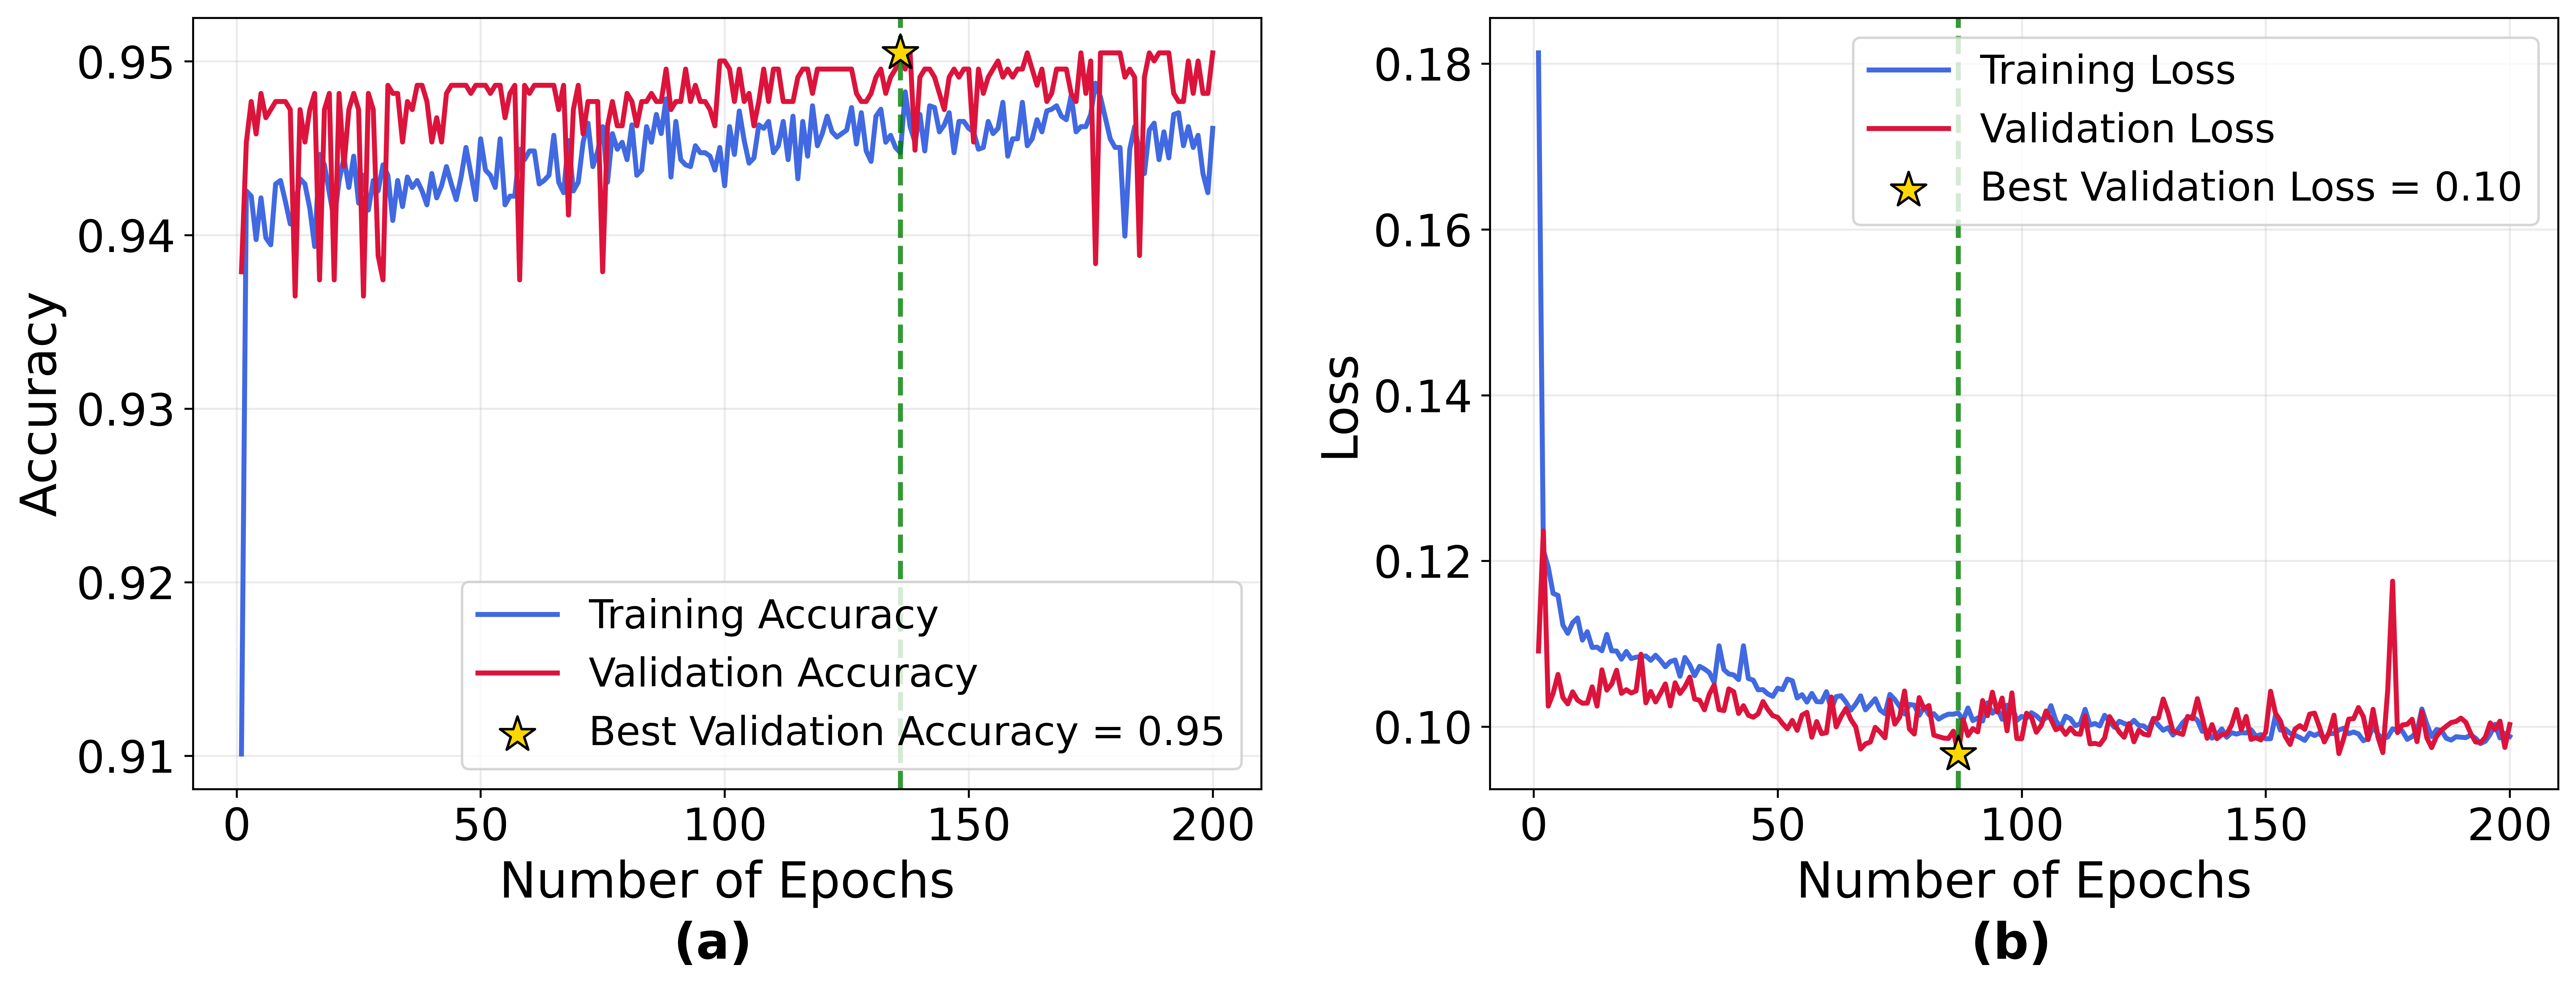

In [17]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report


Evaluation Results: Train
Accuracy  : 0.946541
Precision : 0.910448
Recall    : 0.990379
F1-score  : 0.948733
ROC AUC   : 0.992749
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.989478  0.902800  0.944154      5000
         1.0   0.910448  0.990379  0.948733      4989

    accuracy                       0.946541      9989
   macro avg   0.949963  0.946589  0.946443      9989
weighted avg   0.950007  0.946541  0.946441      9989



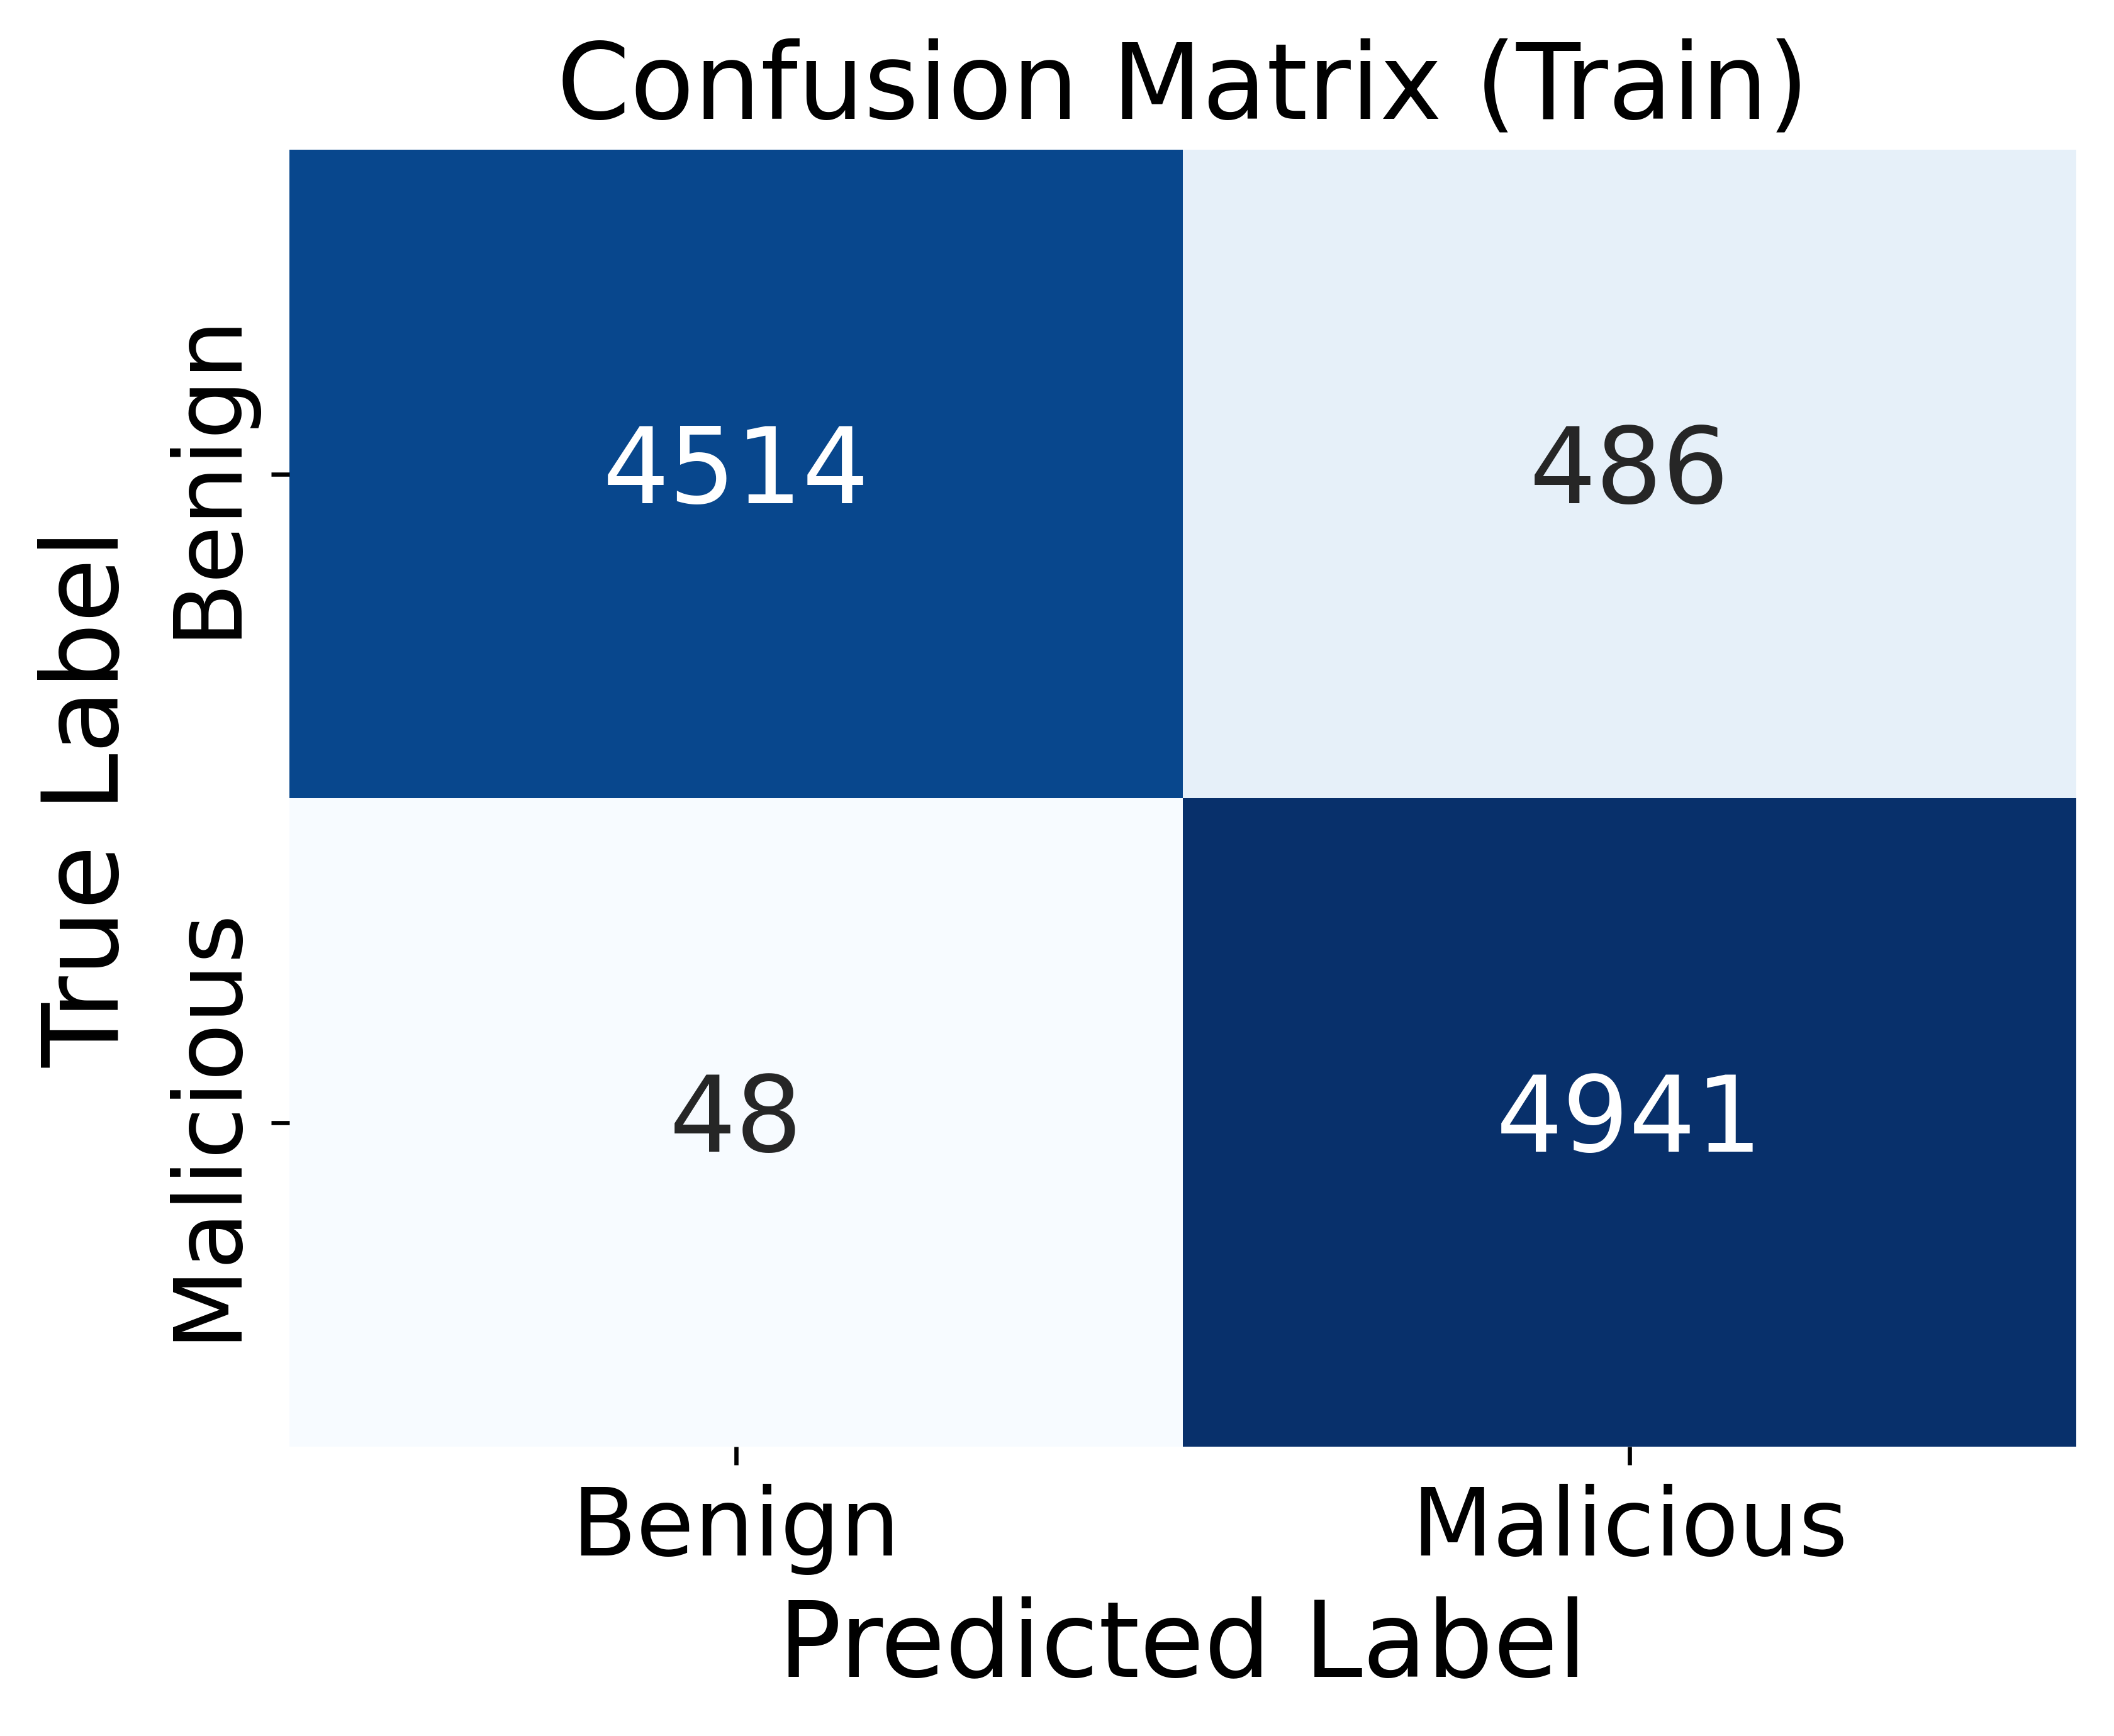

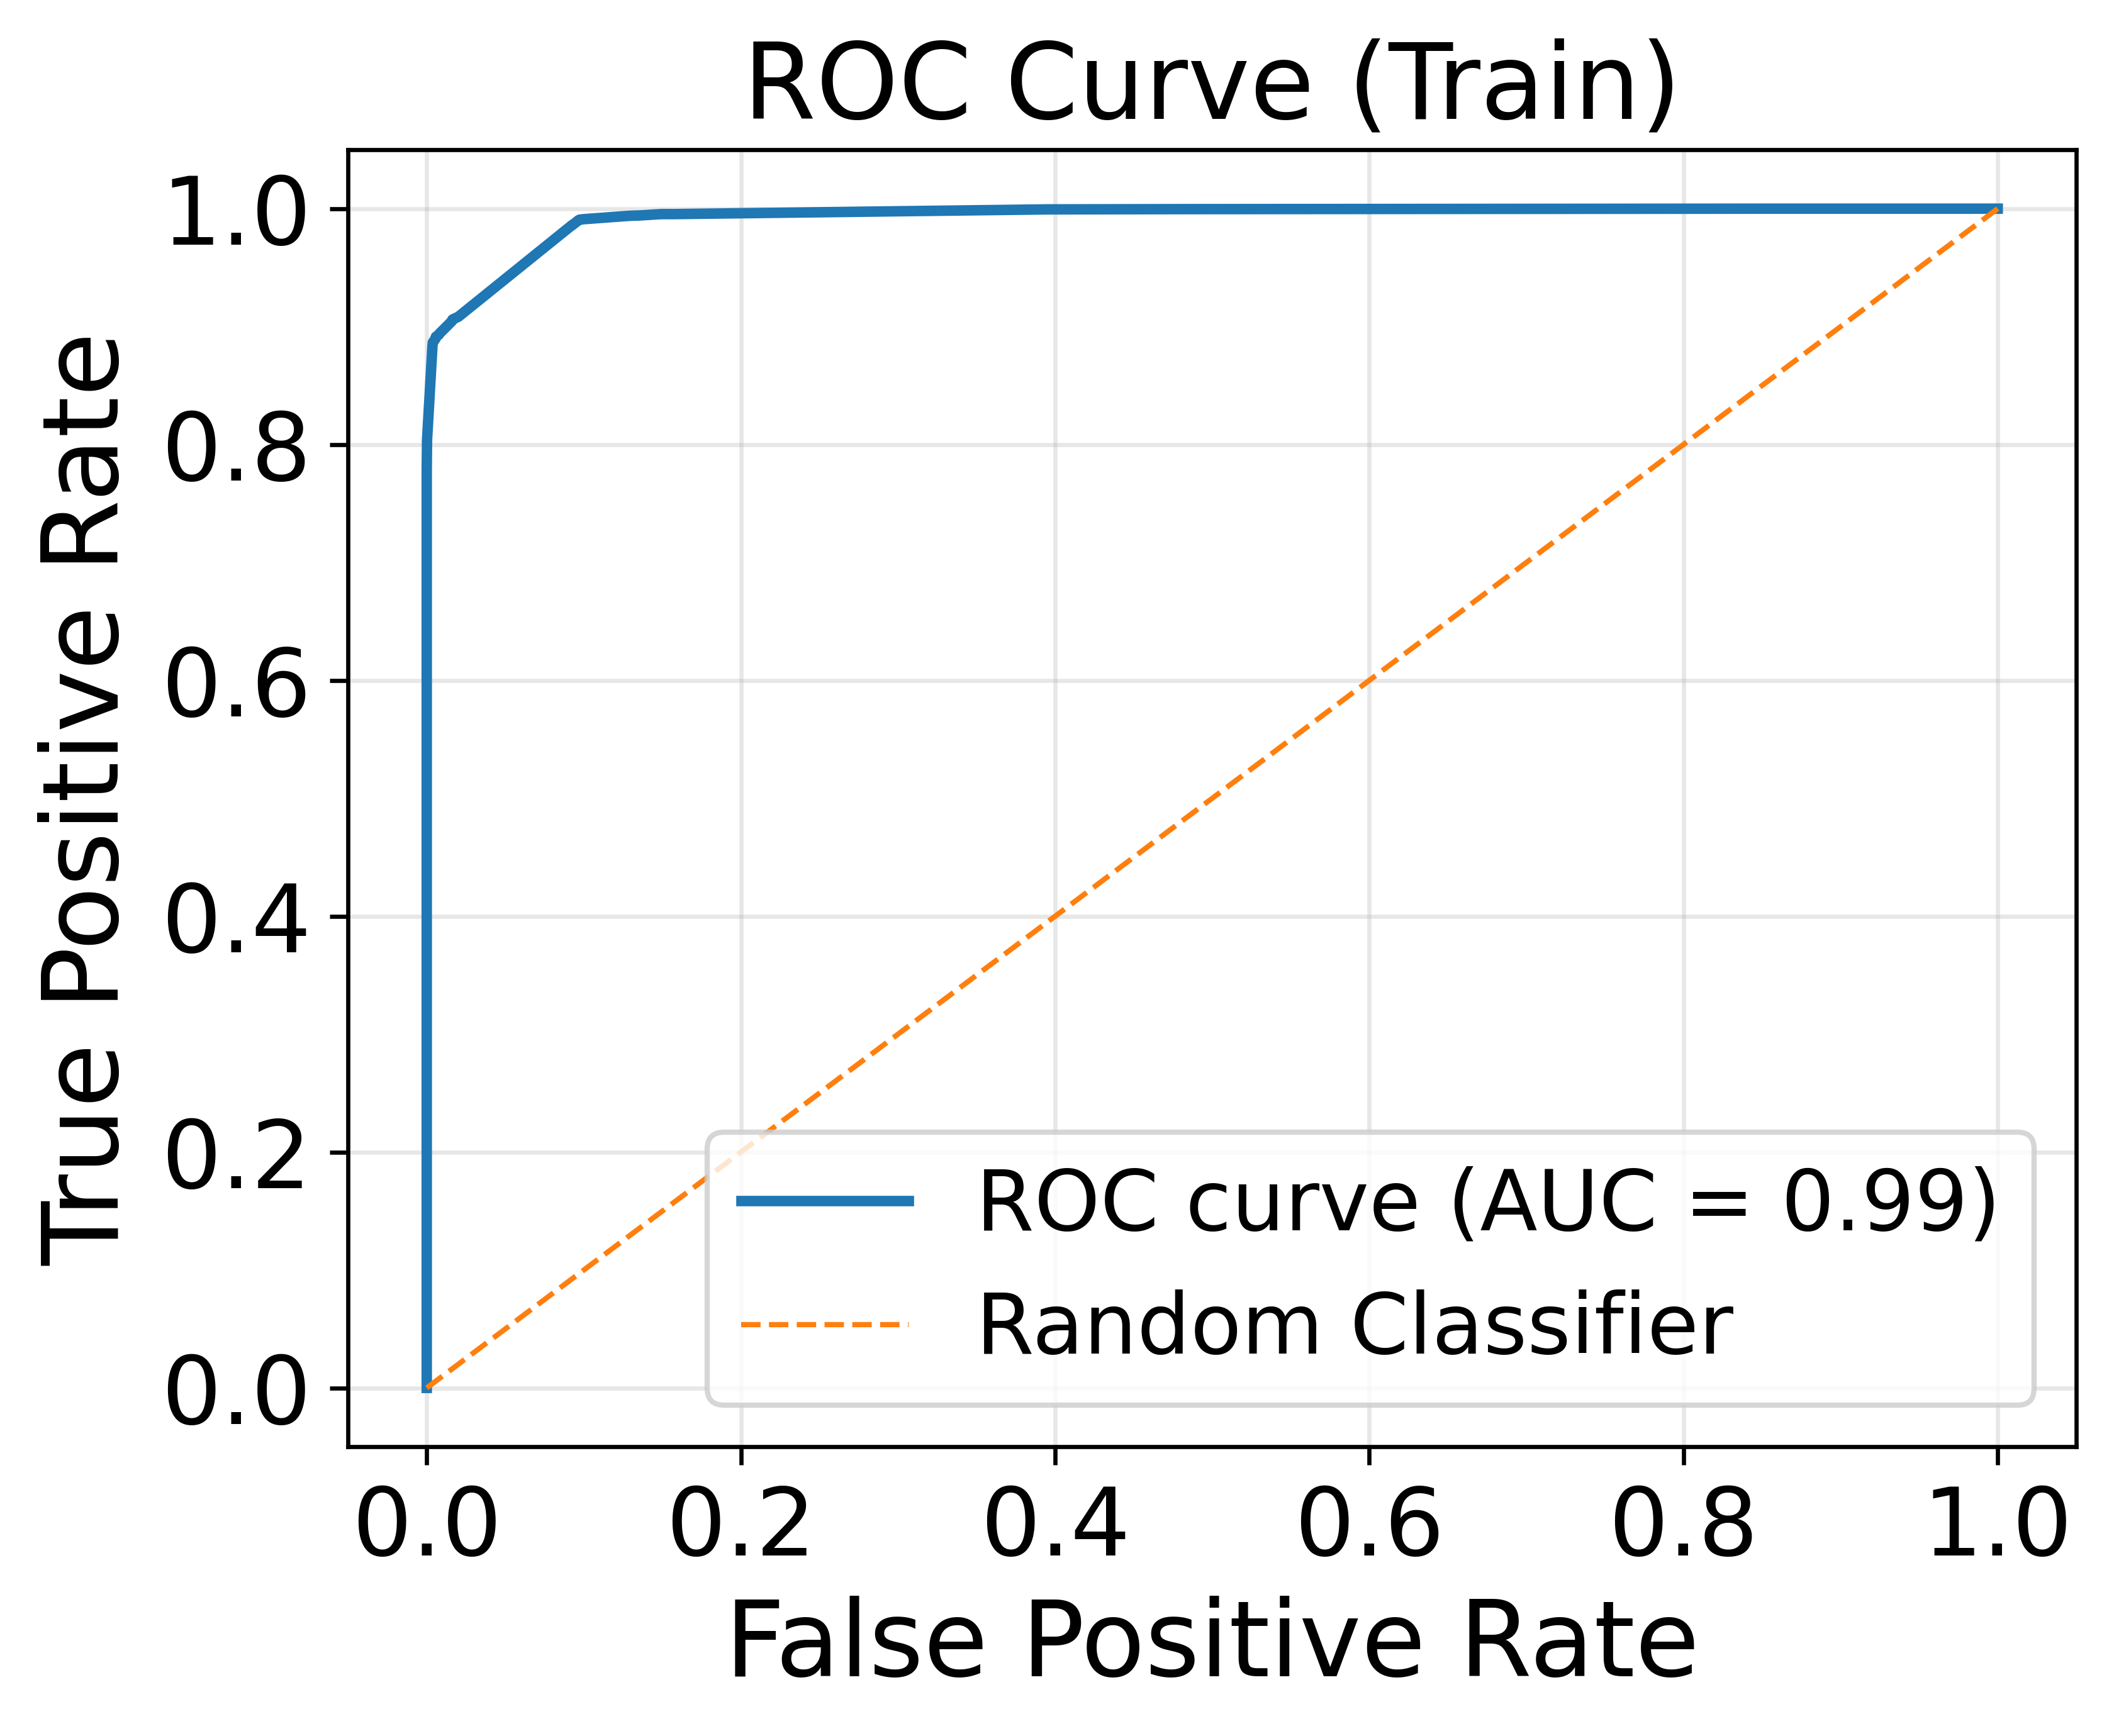


Evaluation Results: Validation
Accuracy  : 0.950490
Precision : 0.914015
Recall    : 0.994387
F1-score  : 0.952509
ROC AUC   : 0.992483
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.993865  0.906716  0.948293      1072
         1.0   0.914015  0.994387  0.952509      1069

    accuracy                       0.950490      2141
   macro avg   0.953940  0.950552  0.950401      2141
weighted avg   0.953996  0.950490  0.950398      2141



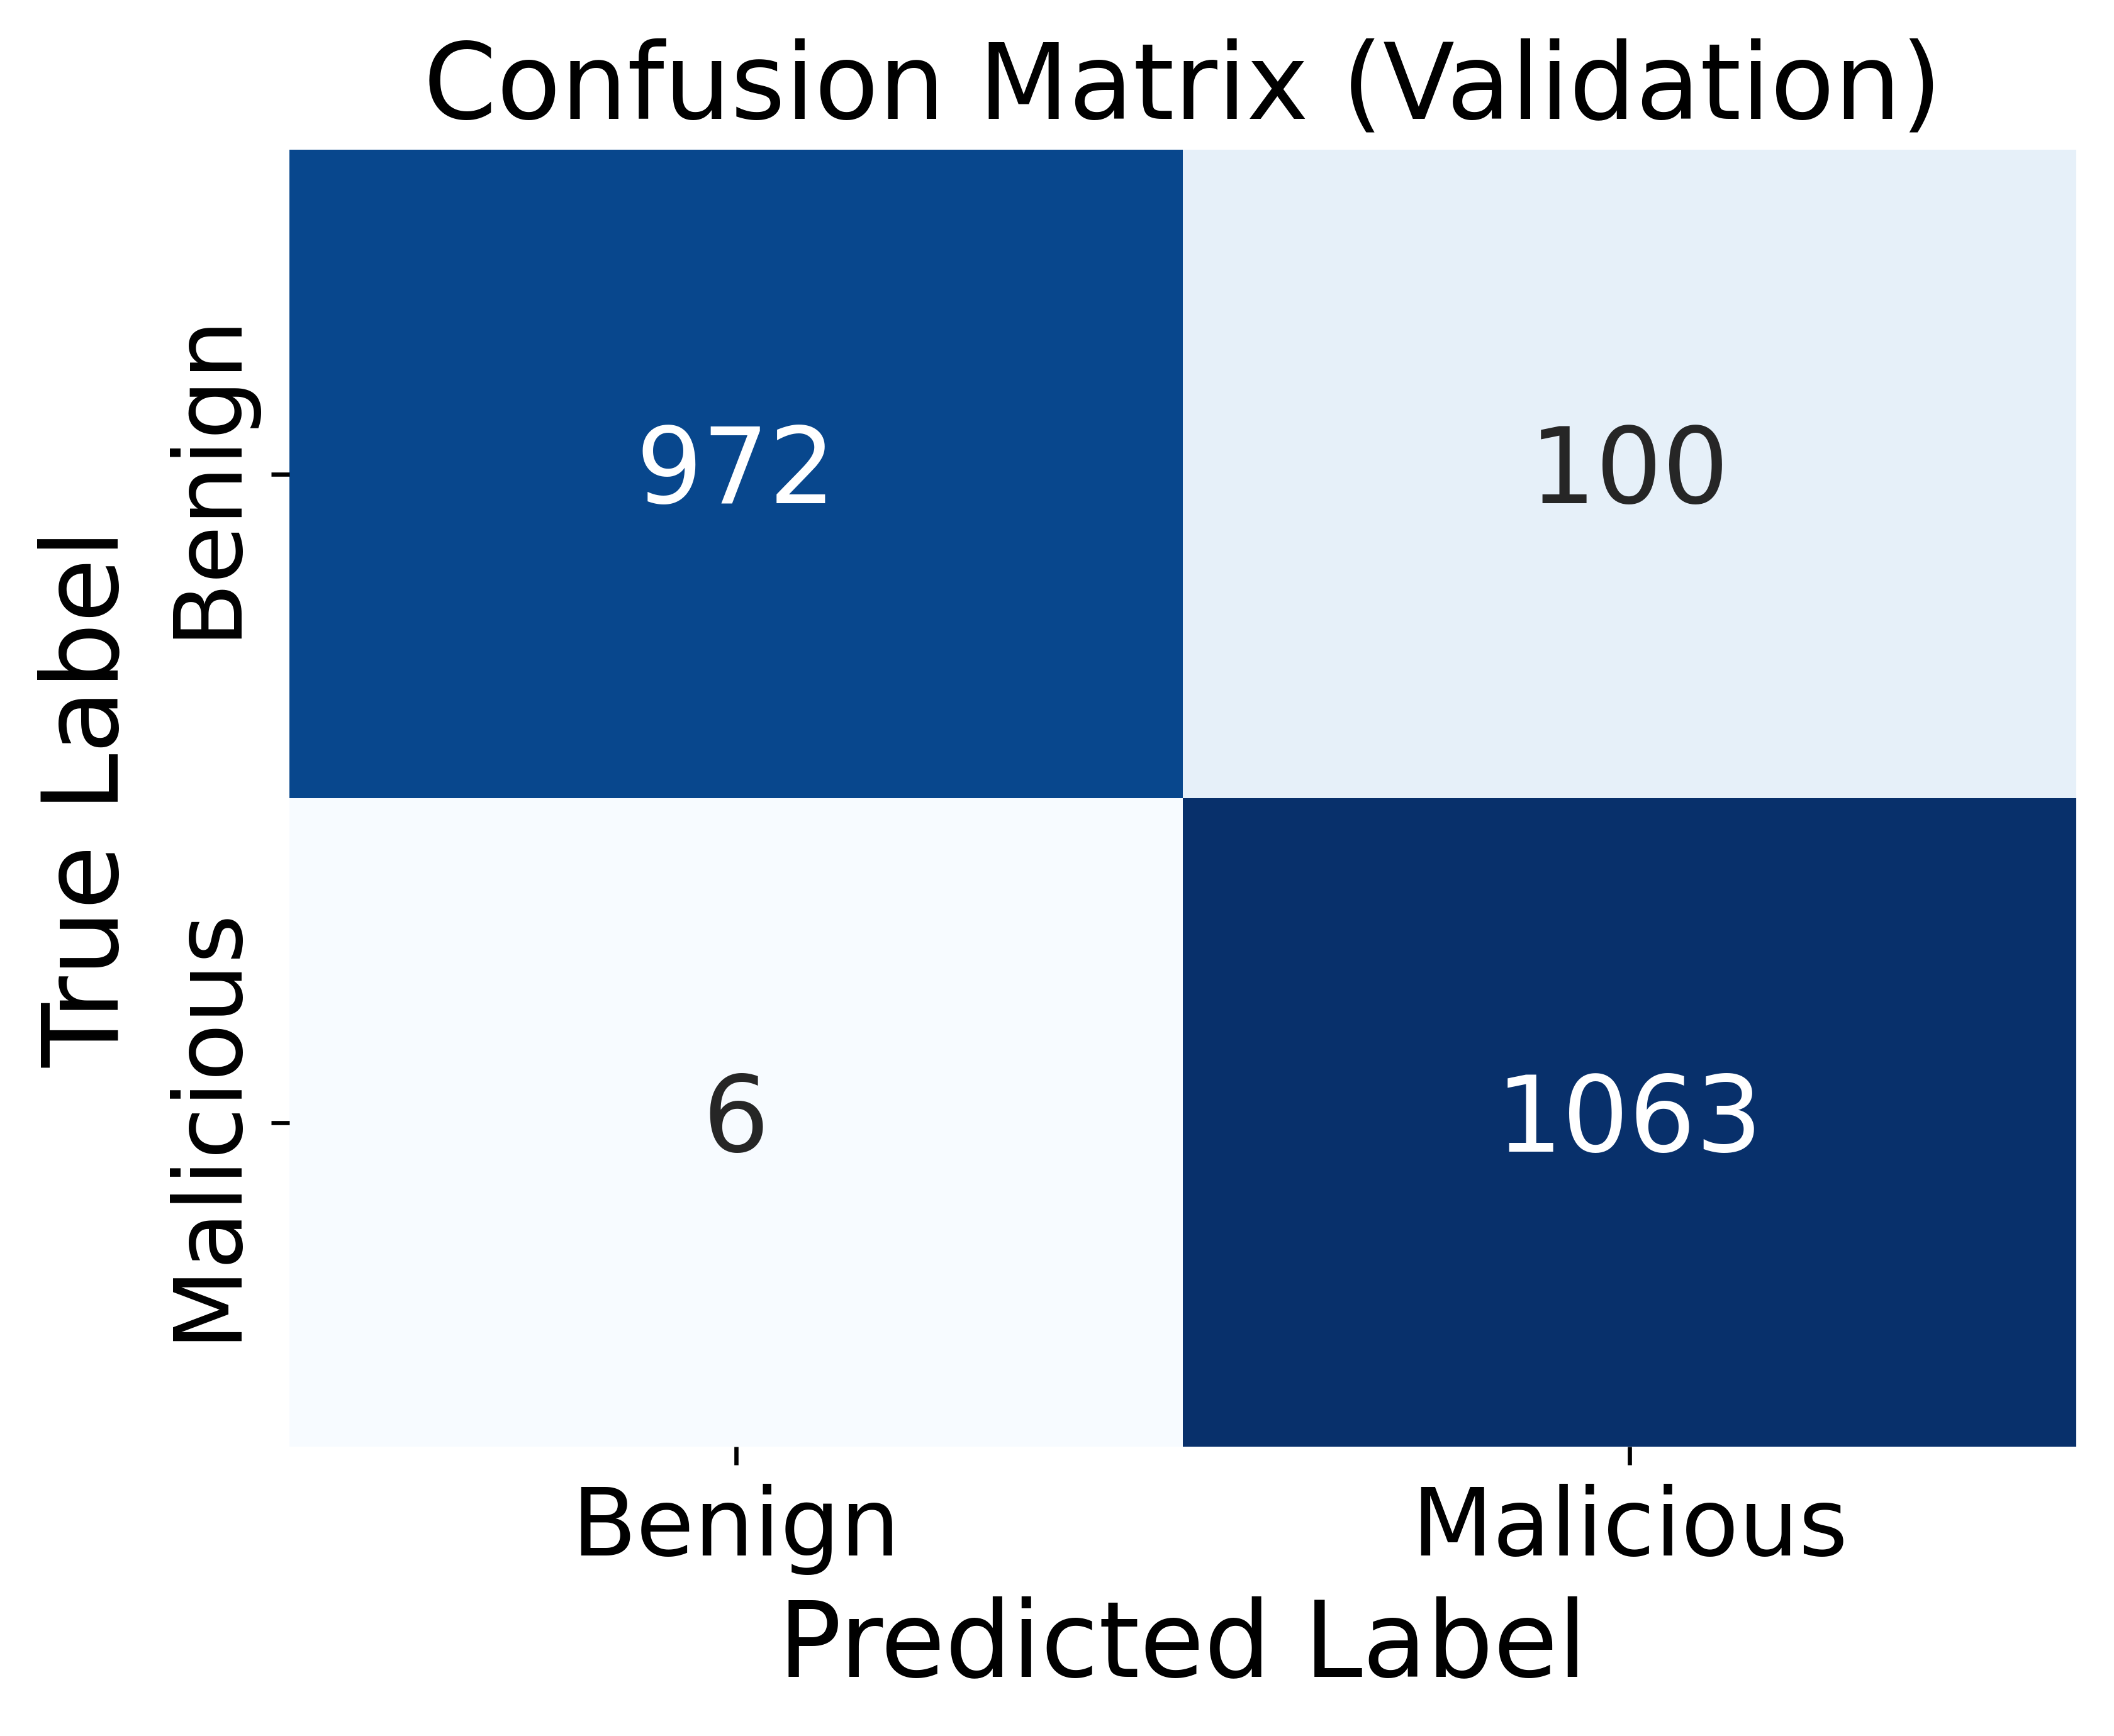

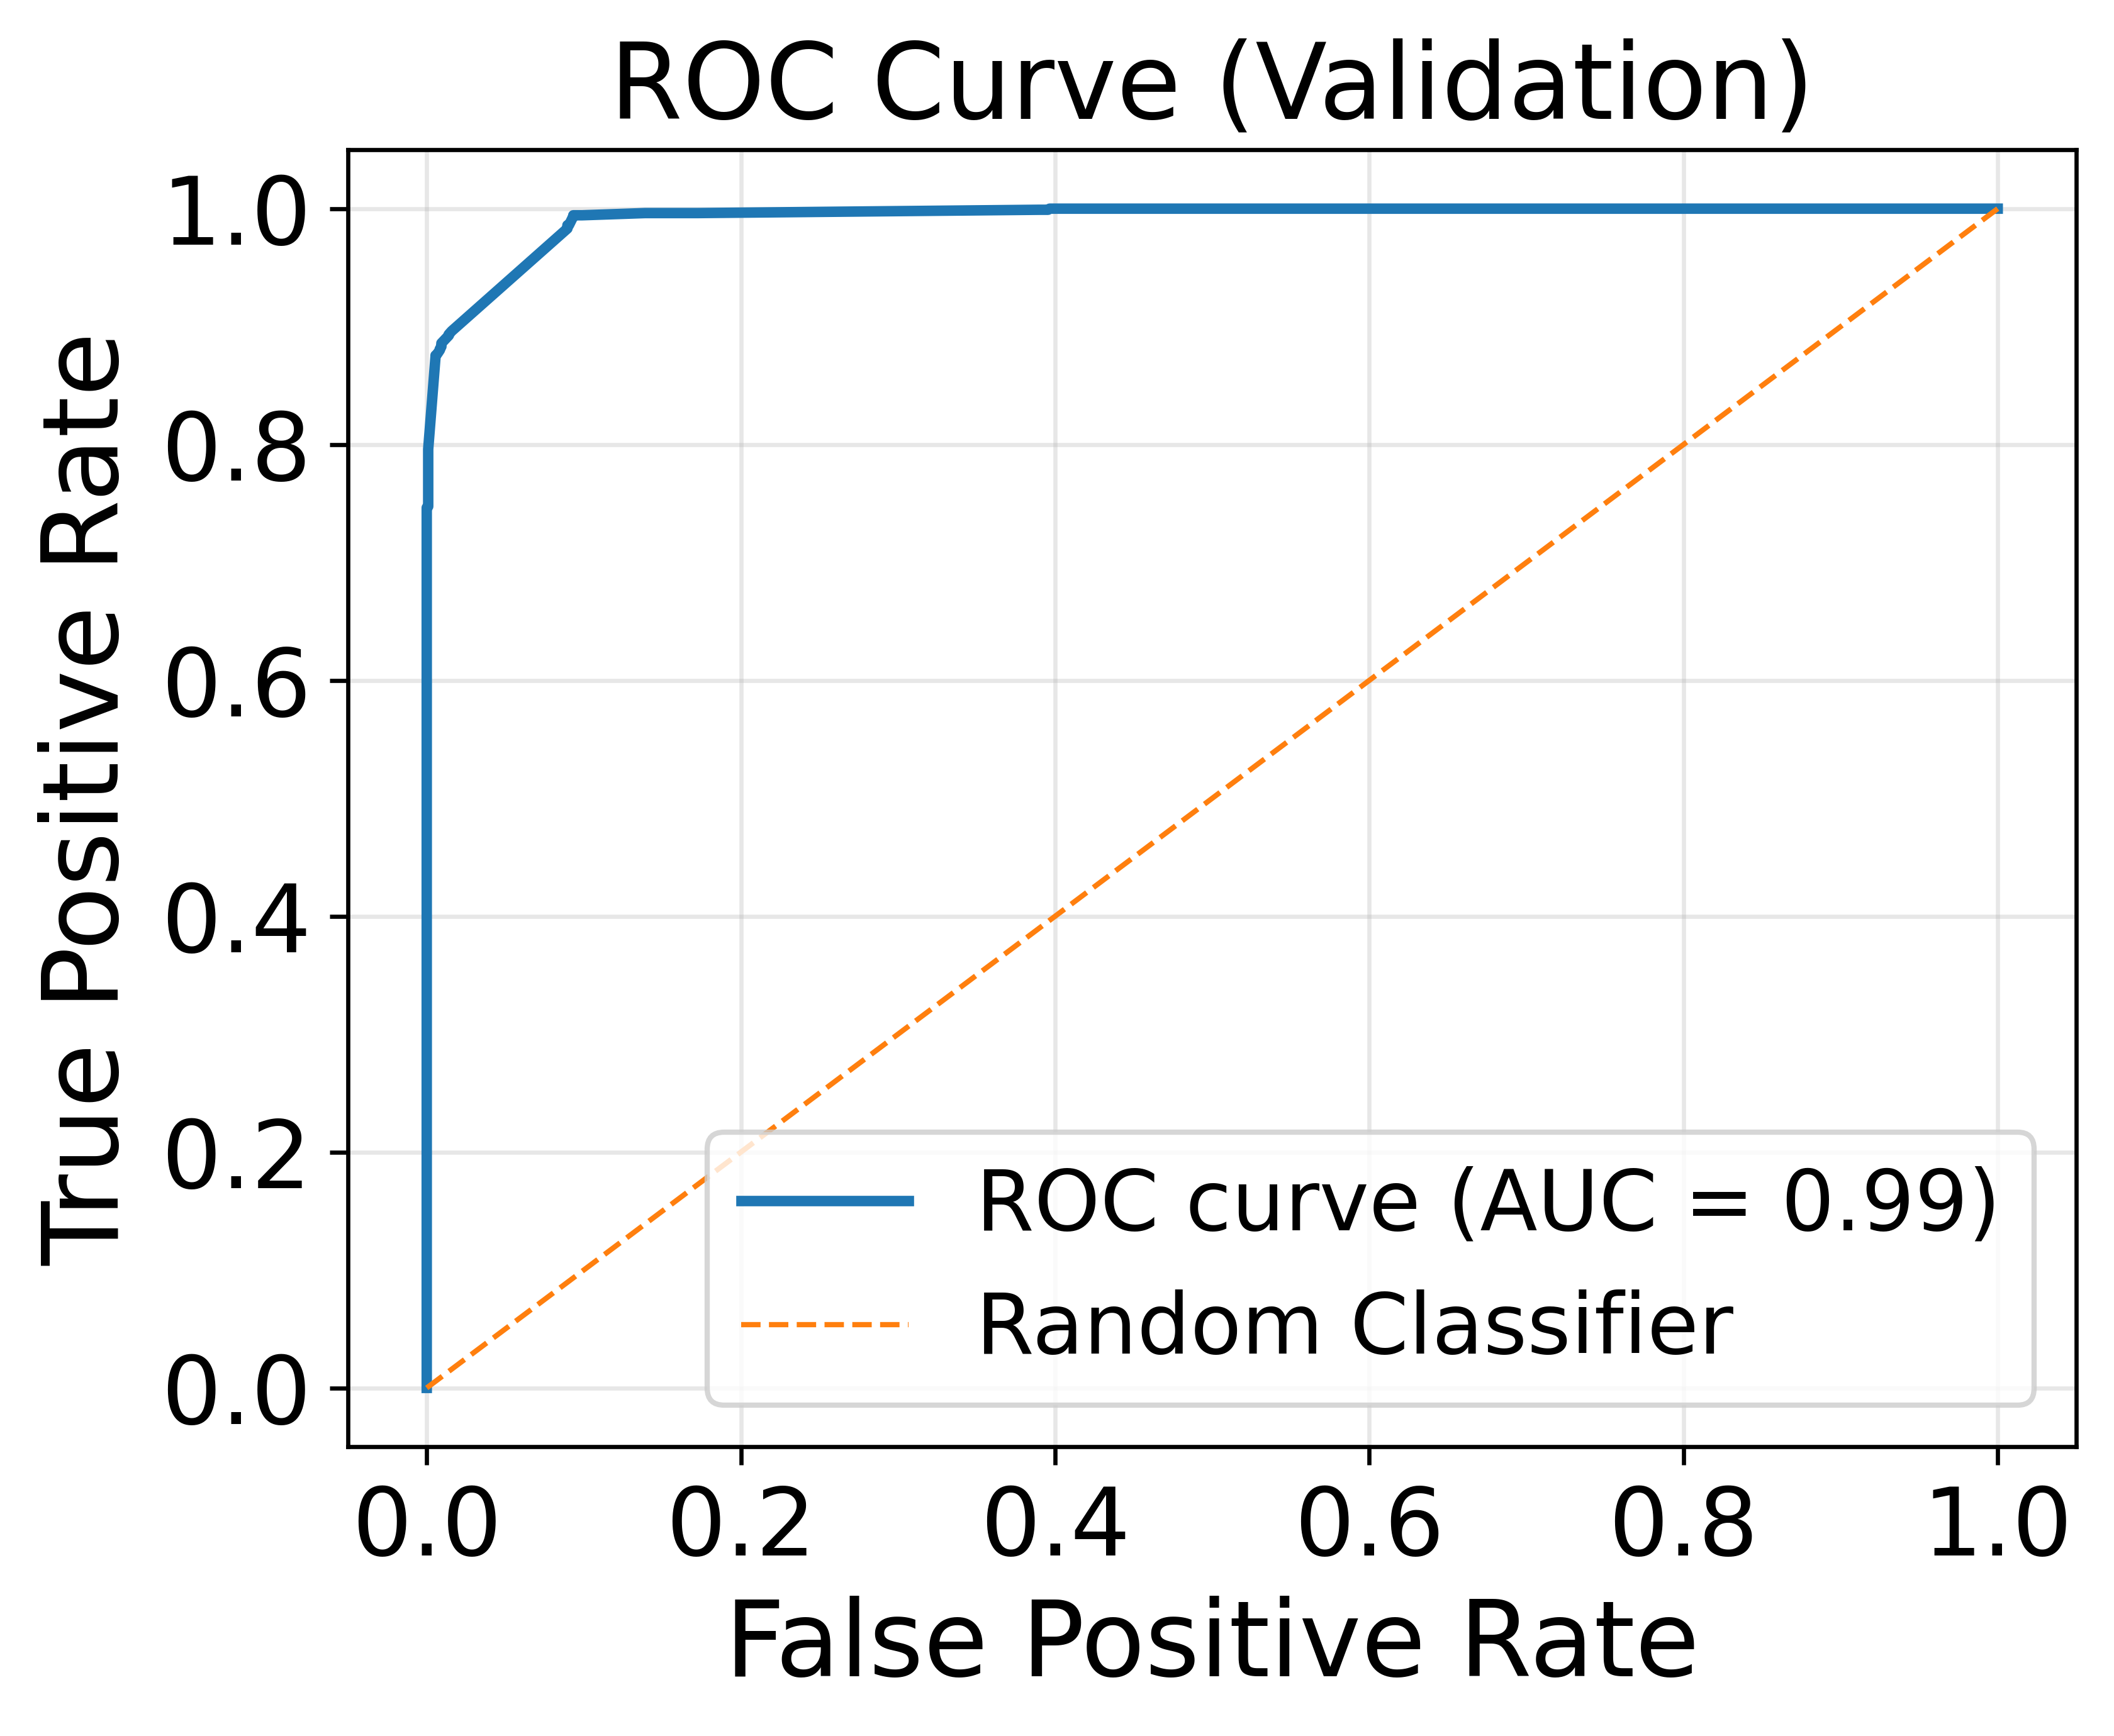


Evaluation Results: Test
Accuracy  : 0.942083
Precision : 0.903501
Recall    : 0.989710
F1-score  : 0.944643
ROC AUC   : 0.991960
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.988660  0.894590  0.939275      1072
         1.0   0.903501  0.989710  0.944643      1069

    accuracy                       0.942083      2141
   macro avg   0.946081  0.942150  0.941959      2141
weighted avg   0.946140  0.942083  0.941955      2141



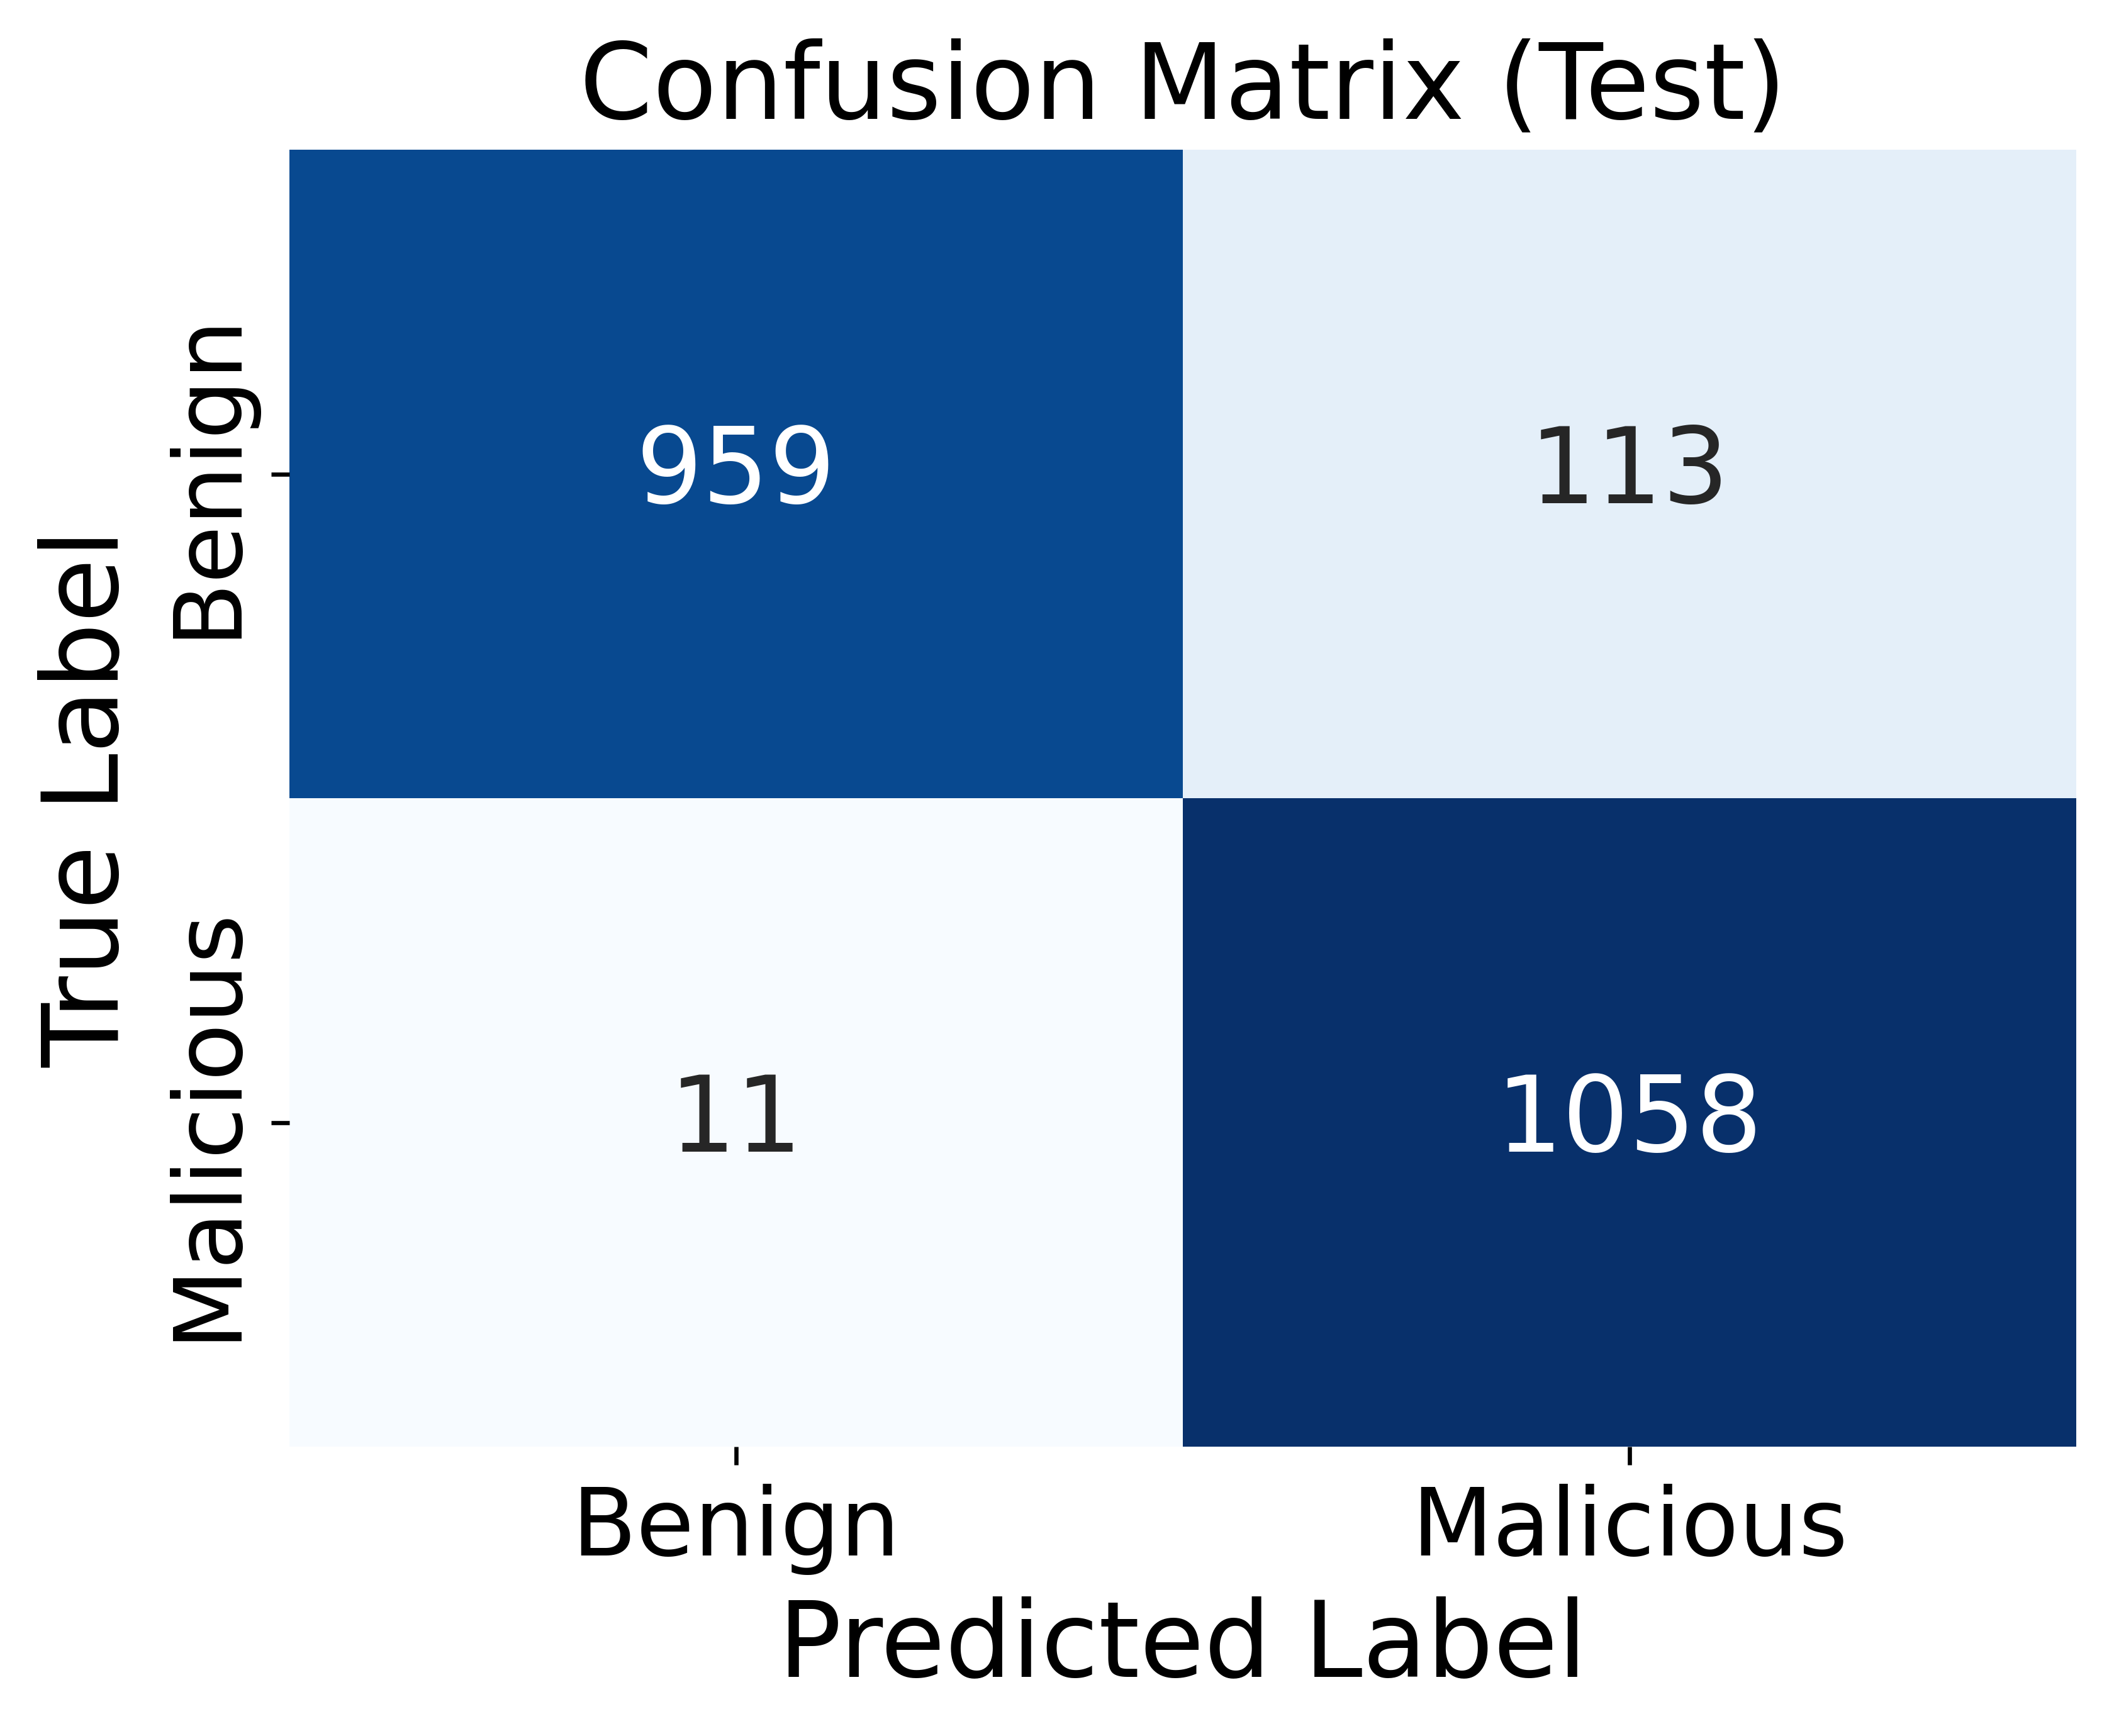

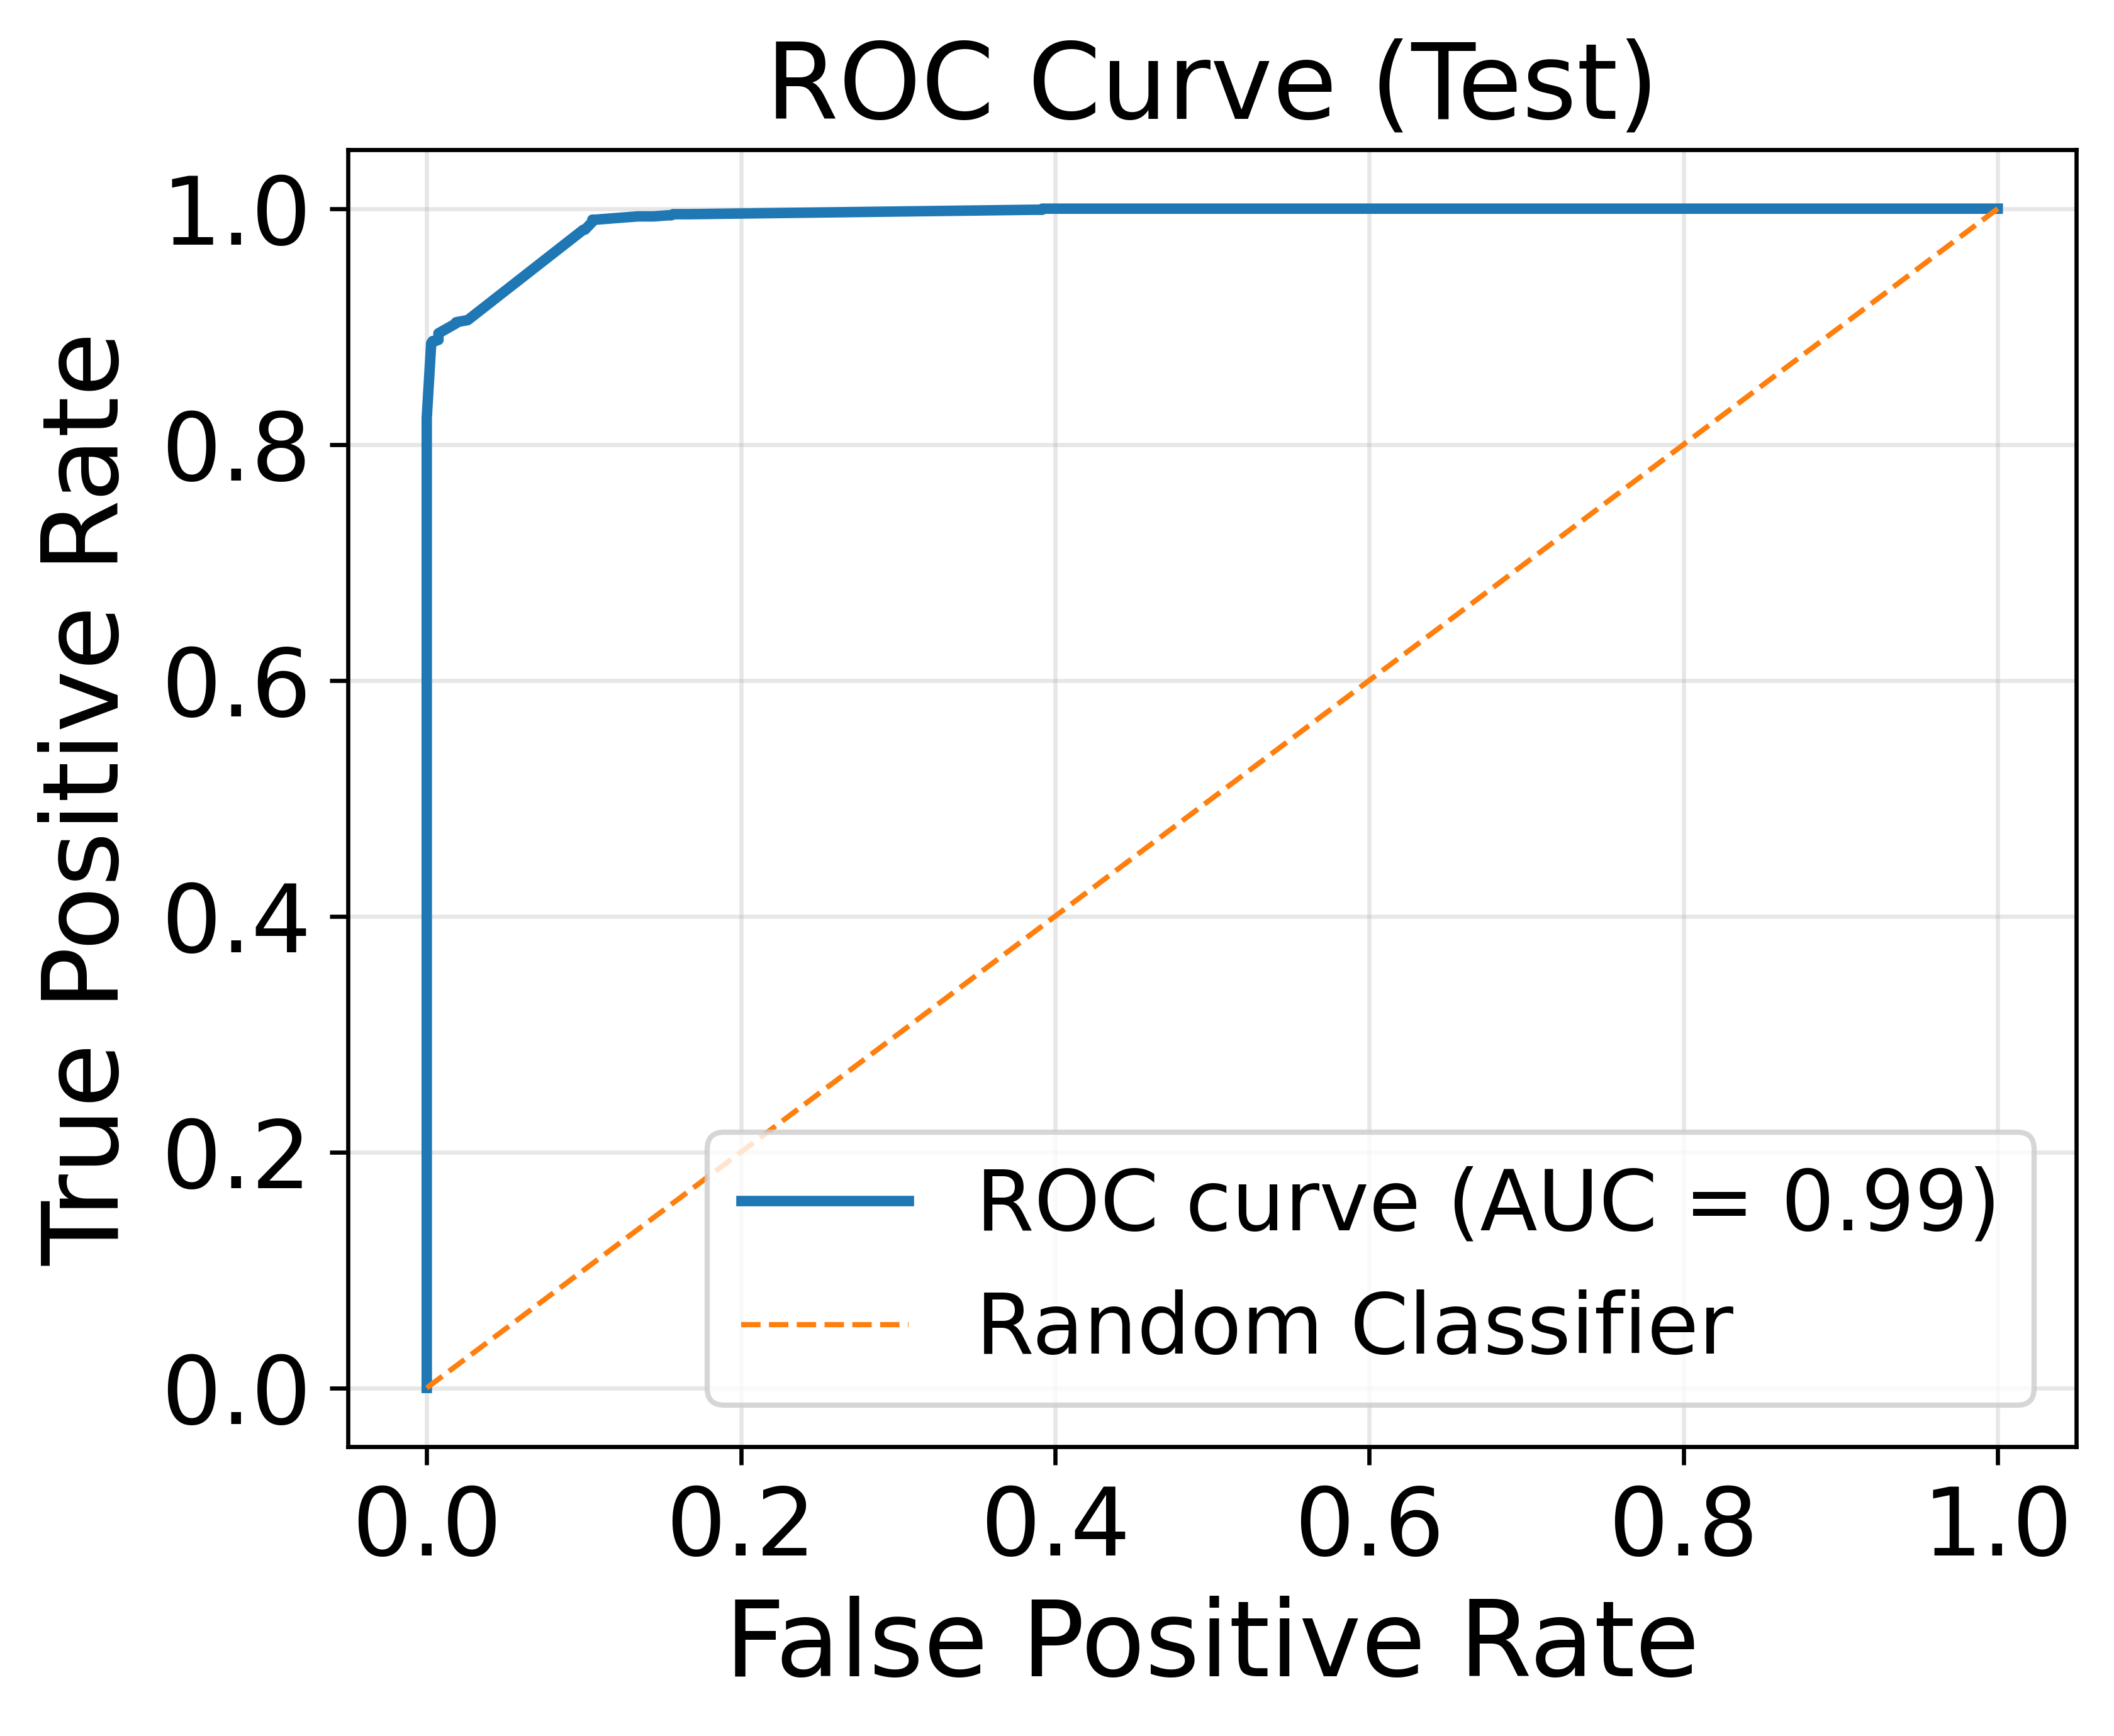

In [18]:
def evaluate_and_plot(model, encodings, X_num, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    X_num : np.ndarray or sparse matrix
        Additional numerical feature matrix.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Prepare model inputs
    # --------------------------------------------------------
    inputs = [
        np.array(encodings["input_ids"]),
        np.array(encodings["attention_mask"]),
        X_num
    ]

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(inputs, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, train_enc, X_train_num, y_train, "Train")
val_results   = evaluate_and_plot(model, val_enc, X_val_num, y_val, "Validation")
test_results  = evaluate_and_plot(model, test_enc, X_test_num, y_test, "Test")

### Save All Results

In [21]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2/evaluation_summary.csv
Excel: Evaluation_Outputs_SysCall_WOA_Attention_DistilGPT2/evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.946541,0.910448,0.990379,0.948733,0.992749
1,Validation,0.950490,0.914015,0.994387,0.952509,0.992483
2,Test,0.942083,0.903501,0.989710,0.944643,0.991960


### Clear Final Backend Session

In [22]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()